# Exploratory data analysis

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter


PROJECT_ROOT = Path("..")

In [3]:
data_path = PROJECT_ROOT / "data/dna_seq_families.csv"
dna_df = pd.read_csv(data_path)
dna_df["seq_len"] = dna_df["dna_sequence"].apply(len)
dna_df

,dna_sequence,gene_family,seq_len
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,207
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,681
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1686
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1206
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,1437
...,...,...,...
4375,ATGGAAGATTTGGAGGAAACATTATTTGAAGAATTTGAAAACTATT...,0,57
4376,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,5883
4377,ATGCAGTCCTTTCGGGAGCAAAGCAGTTACCACGGAAACCAGCAAA...,6,5817
4378,ATGGGGCACCTGGTTTGCTGTCTGTGTGGCAAGTGGGCCAGTTACC...,6,753


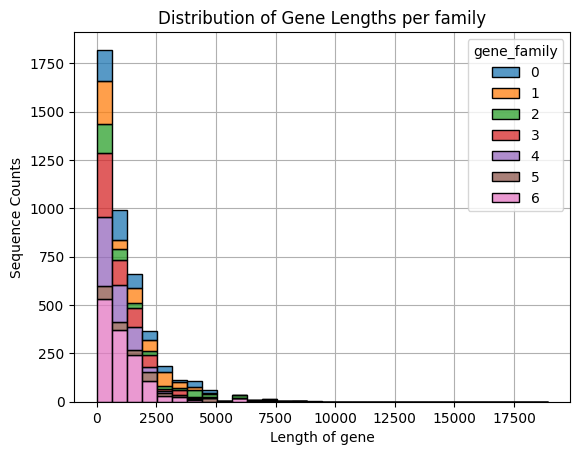

In [6]:
sns.histplot(
    data=dna_df, 
    x="seq_len", 
    hue="gene_family", 
    multiple="stack", # Use "dodge" for side-by-side bars
    palette="tab10",
    bins=30
)
plt.title('Distribution of Gene Lengths per family')
plt.xlabel('Length of gene')
plt.ylabel('Sequence Counts')
plt.grid()
plt.gca().set_axisbelow(True)

Here we see a heavily left-skewed distribution, with seeminly matching distributions of each gene family across the distribution of gene lengths.

In [4]:
print("Sequence Length Breakdown")
print("Min Sequence Length: ", dna_df["seq_len"].min())
print("Max Sequence Length: ", dna_df["seq_len"].max())
print("Median Sequence Length: ", dna_df["seq_len"].median())
print("Seqs < 18 bps:", sum(dna_df["seq_len"] < 18))
print("Seqs > 4092 bps:", sum(dna_df["seq_len"] > 4092))

Sequence Length Breakdown
Min Sequence Length:  5
Max Sequence Length:  18921
Median Sequence Length:  865.0
Seqs < 18 bps: 6
Seqs > 4092 bps: 194


The shortest sequence is only 5 nucleotides long, this will be difficult for most algorithms to classify into a family as it likely only contains one motif. It is unlikely our refined model will be able to process sequences as long as 19,000 bps due to the limited hardware availability. Given that most sequences are closer to 865 we should consider dropping sequence shorter than 18 bps and longer than 4092. This only cuts out 200 sequences out of our initial 4380.

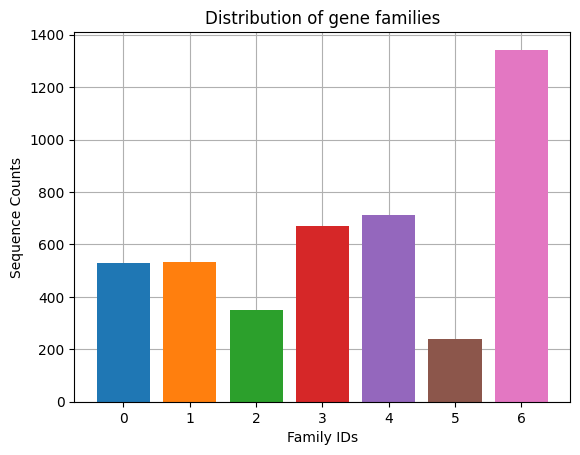

In [25]:
family_counts = dna_df["gene_family"].value_counts().sort_index().to_dict()
plt.bar(family_counts.keys(), family_counts.values(), color=plt.get_cmap("tab10").colors)
plt.title("Distribution of gene families")
plt.xlabel("Family IDs")
plt.ylabel("Sequence Counts")
plt.grid()
plt.gca().set_axisbelow(True)

This plot shows a strong class imbalance, especially between familys 5 and 6. This suggests we need to use stratified sampling and a training loss that accounts for this in the refined model.

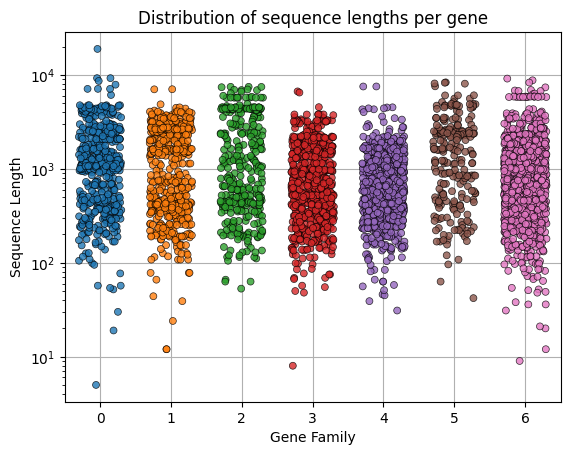

In [12]:
sns.stripplot(
    data=dna_df, 
    x="gene_family", 
    y="seq_len",
    hue="gene_family", 
    palette="tab10",
    edgecolor="black",
    jitter=0.3,
    size=5,
    linewidth=0.5,
    alpha=0.8,
)
plt.yscale("log")
plt.legend().remove()
plt.title("Distribution of sequence lengths per gene")
plt.xlabel('Gene Family')
plt.ylabel('Sequence Length')
plt.grid()
plt.gca().set_axisbelow(True)

This shows that regardless of the gene family we see a similar distribution of gene lengths. This suggests that the gene length has nothing to do with the family, but the motifs of DNA within the genes do.

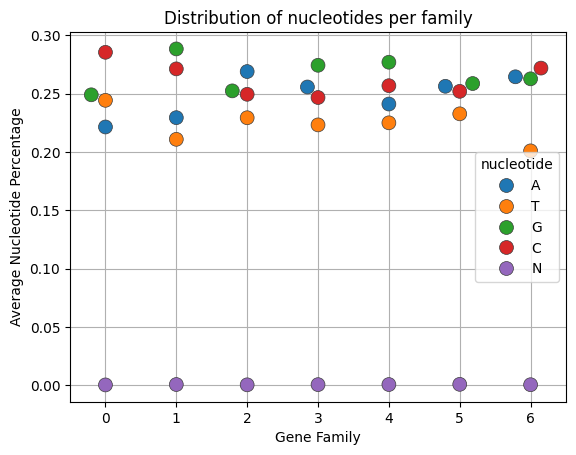

In [8]:
nuc_counts_df = pd.json_normalize(dna_df["dna_sequence"].map(Counter)).fillna(0).div(dna_df["seq_len"], axis=0)
nuc_counts_df["gene_family"] = dna_df["gene_family"]
nuc_counts_df = nuc_counts_df.groupby("gene_family").mean()
nuc_counts_df = nuc_counts_df.reset_index().melt(
    id_vars='gene_family', 
    var_name='nucleotide', 
    value_name='perc'
)
sns.swarmplot(
    nuc_counts_df, 
    x="gene_family", 
    y="perc",
    hue="nucleotide", 
    palette="tab10", 
    size=10,
    linewidth=0.5,
)
plt.title("Distribution of nucleotides per family")
plt.xlabel('Gene Family')
plt.ylabel('Average Nucleotide Percentage')
plt.grid()
plt.gca().set_axisbelow(True)

This shows that the distribution of nucleotide bases within a gene hardly impacts the family the gene belongs to, and that the combinations of nucleotides decide. We also see a small amount of ambiguous N nucleotides. We need to ensure the models are able to handle these.